In [4]:
import pandas as pd 
import numpy as np 
import seaborn  as sns

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression


In [5]:
retail_clean = pd.read_csv('retail_clean.csv')

In [6]:
retail_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779495 entries, 0 to 779494
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   779495 non-null  int64  
 1   Invoice      779495 non-null  int64  
 2   StockCode    779495 non-null  object 
 3   Description  779495 non-null  object 
 4   Quantity     779495 non-null  int64  
 5   InvoiceDate  779495 non-null  object 
 6   Price        779495 non-null  float64
 7   Customer ID  779495 non-null  float64
 8   Country      779495 non-null  object 
 9   Revenue      779495 non-null  float64
dtypes: float64(3), int64(3), object(4)
memory usage: 59.5+ MB


In [7]:
retail_clean.InvoiceDate

0         2009-12-01 07:45:00
1         2009-12-01 07:45:00
2         2009-12-01 07:45:00
3         2009-12-01 07:45:00
4         2009-12-01 07:45:00
                 ...         
779490    2011-12-09 12:50:00
779491    2011-12-09 12:50:00
779492    2011-12-09 12:50:00
779493    2011-12-09 12:50:00
779494    2011-12-09 12:50:00
Name: InvoiceDate, Length: 779495, dtype: object

In [8]:
retail_clean['InvoiceDate']= pd.to_datetime(retail_clean['InvoiceDate'])

In [9]:
retail_clean['date']= retail_clean['InvoiceDate'].dt.strftime("%Y-%m-%d")

In [10]:
retail_clean['date']=pd.to_datetime(retail_clean['date'])

In [11]:
retail_clean['month']= retail_clean.date.dt.month

In [12]:
retail_clean['year']= retail_clean.date.dt.year

In [13]:
retail_clean['week']= retail_clean.date.dt.week

/var/folders/4s/2k6f8yld43jdpvtdt363thnh0000gn/T/ipykernel_10065/2418076922.py:1: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated. Please use Series.dt.isocalendar().week instead.
  retail_clean['week']= retail_clean.date.dt.week


In [14]:
retail_clean.columns

Index(['Unnamed: 0', 'Invoice', 'StockCode', 'Description', 'Quantity',
       'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue', 'date',
       'month', 'year', 'week'],
      dtype='object')

In [15]:
retail_clean.month.describe()

count    779495.000000
mean          7.417110
std           3.422346
min           1.000000
25%           5.000000
50%           8.000000
75%          11.000000
max          12.000000
Name: month, dtype: float64

In [16]:
time_series=retail_clean.groupby(['week','year']).agg(date= ('date','first'),
        total_revenue=('Revenue',np.sum)).reset_index().sort_values('date')

<AxesSubplot:xlabel='date', ylabel='total_revenue'>

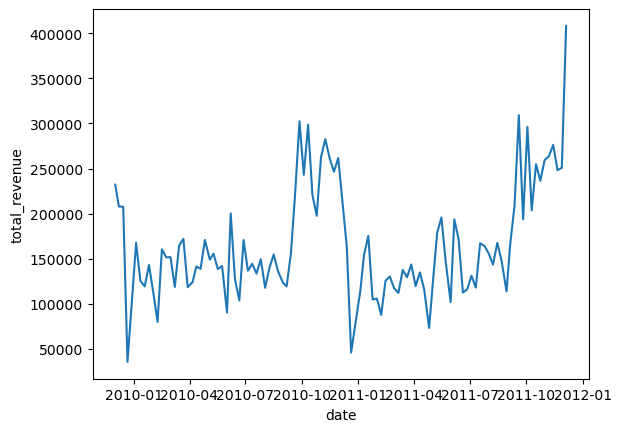

In [17]:
sns.lineplot(x='date', y='total_revenue', data=time_series)

In [21]:
time_series['trend'] = range(time_series.shape[0])


In [22]:
X= time_series.drop(['week','year','date','total_revenue'],axis=1)

In [23]:
names=pd.get_dummies(X).columns

In [24]:
X= pd.get_dummies(X).values

In [25]:
y= time_series.total_revenue.values

In [26]:
model= LinearRegression()

In [27]:
model.fit(X,y)

LinearRegression()

In [28]:
model.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'normalize': 'deprecated',
 'positive': False}

In [29]:
model.coef_

array([658.49168277])

In [30]:
dict1= list(zip(names,model.coef_))

In [31]:
prediction= model.predict(X)

In [32]:
time_series['prediction']= prediction

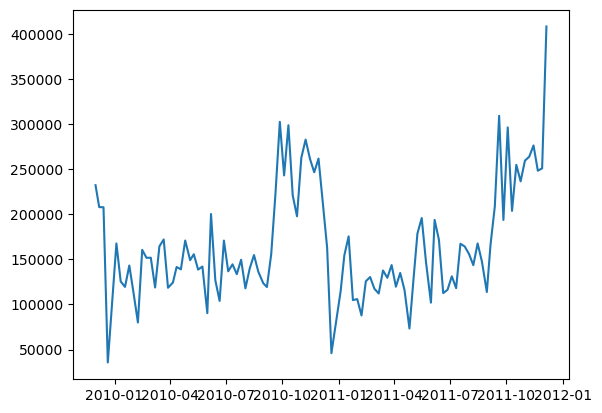

In [33]:
plt.plot(time_series.date,time_series.total_revenue,label='Actual')

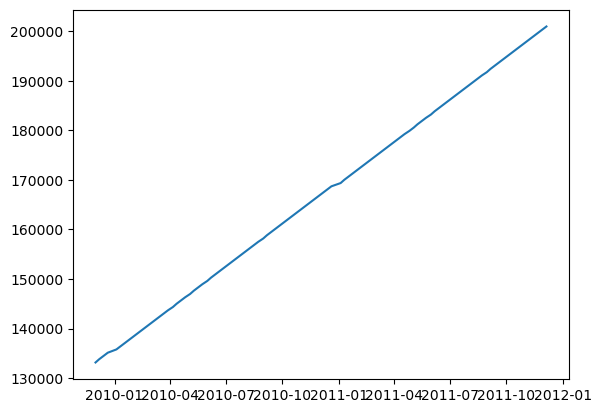

In [34]:
plt.plot(time_series.date,time_series.prediction,label='prediction')